<a href="https://colab.research.google.com/github/rayonli/ITA-Entregas/blob/Sprint-8/Sprint8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Nivel 1

##Exercici 1: Exploració inicial del dataset

En aquest exercici has de realitzar una exploració inicial del DataFrame per respondre, com a mínim, a les següents preguntes:

» Quantes files i columnes té el dataset?
» Quin tipus de dades conté cada columna?
» Hi ha files duplicades?
» Les dades semblen coherents a primera vista?
» Detectes possibles problemes o inconsistències evidents?
Per fer-ho, hauràs de:

» Analitzar les dimensions del dataset
» Mostrar una mostra representativa de files
» Revisar els tipus de variables
» Les dades semblen coherents a primera vista?
» Detectar files duplicades
» Identificar i descriure possibles problemes inicials (sense solucionar-los encara)

In [2]:
import pandas as pd

# Cargar dataset:

df = pd.read_excel("sprint8_complex.xlsx", header=3)

# 1. Dimensiones:

print("Dimensiones del dataset:")
print(df.shape)

# 2. Mostrar muestra:

print("\nPrimeras 5 filas:")
print(df.head())

# 3. Información:

print("\nInformación del DataFrame:")
df.info()

# 4. Tipos de datos:

print("\nTipos de datos:")
print(df.dtypes)

# 5. Filas duplicadas:

print("\nFilas duplicadas:")
print(df.duplicated().sum())

# 6. Valores nulos:

print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset:
(1007, 20)

Primeras 5 filas:
   Unnamed: 0    Nom      Cognoms        DNI País d'origen      Ciutat  \
0           0  Joana  Gil Navarro  66722344X       Espanya  Valladolid   
1           1   Marc       MuÃ±oz  48840994W       Espanya     Alacant   
2           2    Noa        Serra  14308421X       Espanya     Alacant   
3           3    Pol          Gil  58586340F       Espanya     Sevilla   
4           4  David         Vila  82070937P       Espanya      Bilbao   

   Dia de Naixement  Mes de Naixement  Any de Naixement Gènere Salari mensual  \
0              23.0               3.0            1958.0   Dona      1,469 â‚¬   
1               8.0              11.0            1960.0      H      2,718 â‚¬   
2              27.0               4.0            1961.0      D     1358 euros   
3              13.0              10.0            1985.0      H      1,478 â‚¬   
4              29.0              11.0            1965.0   Dona      1,284 â‚¬   

  Fills No Fi

###Respuesta: El dataset contiene 1007 registros y 20 variables.
-No se han detectado filas duplicadas, aunque sí existen numerosos valores nulos en varias columnas (número de hijos, uso del coche, kilómetros recorridos y consumo de combustible).
-Algunas variables deberían ser numéricas ("Salari mensual" o "Fills"), pero aparecen como tipo object.
-También se aprecia un problema en el nombre de la columna "CÃ rrec".

En los siguientes ejercicios será necesario tratar los valores perdidos, corregir los tipos de datos, revisar los nombres de las columnas y resolver posibles inconsistencias antes de realizar cualquier análisis.

##Exercici 2: Validacions bàsiques de les dades i decisions d'eliminació
🎯 Objectiu: assegurar que les dades compleixen unes condicions mínimes de qualitat i determinar quines files poden continuar sent analitzades i quines s'han de descartar.
En aquest exercici hauràs de validar aspectes clau del dataset que són crítics en qualsevol context real d'anàlisi de dades, prenent decisions justificades sobre la validesa o eliminació de registres.

Aspectes a validar:

» Existeixen identificadors únics (DNI) per a cada persona?
» Què faràs amb les files duplicades o registres repetits?
» Hi ha valors obligatoris que falten o informació incoherent?
» Detectes formats incorrectes, errors de codificació o valors impossibles?
Concretament, hauràs de:

» Corregir possibles problemes de codificació i accentuació en els noms de les columnes i en els valors de text, si escau.
» Detectar i eliminar files duplicades exactes, indicant quants registres s'han eliminat.
» Comprovar la unicitat del DNI. En cas de detectar DNIs duplicats, hauràs d'analitzar la coherència de la informació associada i descartar o anul·lar els registres que no siguin fiables, justificant clarament la decisió presa.
» Identificar els camps clau que no haurien de contenir valors nuls, detectar registres amb informació insuficient i eliminar únicament aquelles files completament buides o amb informació irrecuperable o no substituïble, explicant per què no és possible ni raonable imputar-les.
 Important

en aquest exercici no s'espera que imputis dades, sinó que decideixis quins registres poden formar part de l'anàlisi i quins no, argumentant sempre el criteri utilitzat.

🧠 Si el text "s'entén però està mal escrit" → codificació

Si el text "està ben escrit però no és útil per a l'anàlisi" → validació

In [3]:
from numpy import nan
import pandas as pd

# Cargar el dataset:

df = pd.read_excel("sprint8_complex.xlsx", header=3)

# 1. Buscar y corregir nombres de columnas:

df.columns = (
    df.columns
      .str.replace("CÃ\xa0rrec", "Càrrec")
      .str.replace("Unnamed: 0", "Id")
)

# 2. Buscar y corregir errores de codificación en texto

# Normalizamos la columna Nom:

df["Nom"] = (
    df["Nom"]
        .astype(str)
        .str.strip()
)

df["Nom"] = df["Nom"].replace({
    "AdriÃ": "Adrià",
    "VÃ­ctor": "Víctor",
    "Ã‰lise": "Èlise",
    "LÃ©a": "Lía",
    "LucÃ­a": "Lucía",
    "ChloÃ©": "Chloé",
    "NÃºria": "Núria",
    "ZoÃ©": "Zoé"
})

# Normalizamos la columna Cognoms:

print(df["Cognoms"].nunique())

reemplazos = {
    "GÃ³mez": "Gómez",
    "PÃ©rez": "Pérez",
    "MuÃ±oz": "Muñoz",
    "DÃ­az": "Díaz",
    "LÃ³pez": "López",
    "GarcÃ\xada": "García",
    "DÃ\xadaz": "Díaz",
    "HernÃ¡ndez": "Hernández",
    "FernÃ¡ndez": "Fernández",
    "DomÃ¨nech": "Domènech",
    "Ã\x81lvarez": "Álvarez",
    "SÃ¡nchez": "Sánchez",
    "MÃ¼ller": "Müller",
    "SchrÃ¶der": "Schröder",
    "SchÃ¤fer": "Schäfer",
    "MartÃ\xadnez" : "Martínez"
}

df["Cognoms"] = df["Cognoms"].replace(reemplazos, regex=True)

# Eliminamos apellido "###":

df = df[df["Cognoms"] != "###"]

# Normalizamos País de origen:

df["País d'origen"] = df["País d'origen"].replace({
    "FranÃ§a": "França",
    "ItÃ\xa0lia": "Itália",
    "Alemanya": "Alemanya"
})

# Normalizamos fecha de nacimiento:

df.loc[
    (df["Dia de Naixement"] < 1) |
    (df["Dia de Naixement"] > 31),
    "Dia de Naixement"
] = pd.NA

df.loc[
    (df["Mes de Naixement"] < 1) |
    (df["Mes de Naixement"] > 12),
    "Mes de Naixement"
] = pd.NA

df.loc[
    (df["Any de Naixement"] < 1900) |
    (df["Any de Naixement"] > 2025),
    "Any de Naixement"
] = pd.NA

# Normalizamos ciudades:

df["Ciutat"] = df["Ciutat"].replace({
    "A CoruÃ±a": "A Coruña",
    "DÃ¼sseldorf": "Düsseldorf",
    "KÃ¶ln": "Köln",
    "MÃ\xa0laga": "Málaga",
    "TromsÃ¸": "Tromso",
    "ValÃ¨ncia": "València",
    "MÃ¼nchen": "München",

})

# Normalizamos la columna Càrrec:

df["Càrrec"] = (
    df["Càrrec"]
        .astype(str)
        .str.strip()
)

# Eliminamos registros sin cargo:

df = df.dropna(subset=["Càrrec"])

df = df[
    (df["Càrrec"] != "???") &
    (df["Càrrec"] != "")
]

# Unificamos categorías:

df["Càrrec"] = df["Càrrec"].replace({
    "TÃ¨cnic IT": "Tècnic IT",
    "Cap de projecte": "Cap de Projecte",
    "Project lead": "Cap de Projecte",
    "Analyst": "Analista",
    "Data Analyst": "Data analyst",
    "Admin.": "Administratiu"
})

# 3. Eliminación filas duplicadas exactas

duplicadas = df.duplicated().sum()

print("Filas duplicadas:", duplicadas)

df = df.drop_duplicates()

print("Filas después de eliminar duplicados:", len(df))

# Normalizamos formato del DNI:

df["DNI"] = (
    df["DNI"]
      .str.upper()
      .str.strip()
      .str.replace(" ", "", regex=False)
)

# 4. Comprobación unicidad del DNI

dni_duplicados = df[df["DNI"].duplicated(keep=False)]

print("Registros con DNI duplicado:")
print(dni_duplicados[["DNI","Nom","Cognoms"]])

# Buscamos DNIs conflictivos (mismo DNI con nombres o apellidos distintos):

dni_conflictivos = (
    df.groupby("DNI")[["Nom", "Cognoms"]]
      .nunique()
)

dni_conflictivos = dni_conflictivos[
    (dni_conflictivos["Nom"] > 1) |
    (dni_conflictivos["Cognoms"] > 1)
]

print("\nDNIs conflictivos:")
print(dni_conflictivos)

# Eliminamos registros con DNI conflictivo:

df = df[
    ~df["DNI"].isin(dni_conflictivos.index)
]

# 5. Eliminación registros sin información imprescindible

campos_obligatorios = [
    "Nom",
    "Cognoms",
    "DNI"
]

antes = len(df)

df = df.dropna(subset=campos_obligatorios)

eliminadas = antes - len(df)

print("Filas eliminadas por falta de información obligatoria:", eliminadas)


# 6. Eliminación registros DNI repetidos (me quedo con los completos)

df["completado"] = df.notna().sum(axis=1)

df = df.sort_values(by="completado", ascending=False)

df = df.drop_duplicates(subset=["DNI"], keep="first")

df = df.drop(columns="completado")

# 7. Comprobación filas completamente vacías

antes = len(df)

df = df.dropna(how="all")

print("Filas finales:", len(df))
print("Filas eliminadas completamente vacías:", antes - len(df))

468
Filas duplicadas: 0
Filas después de eliminar duplicados: 1006
Registros con DNI duplicado:
            DNI      Nom          Cognoms
25    90585882A     Sara            Serra
36    55283701C      Ida  Karlsen Eriksen
40    55283701C      Ida  Karlsen Eriksen
89    54013571W  Guillem      Pujol Costa
104   90585882A    Oriol      Vila Casals
114   90585882A      Pol            Serra
142   54013571W    Marta             Ruiz
250   15909601K     Laia     Navarro Vila
281   90585882A   Xavier            Vidal
372   97954019T     Alba            Muñoz
558   49529438G   Alexia       Pérez Díaz
604   15909601K     Laia          Navarro
654   16618423V    Oriol            Gómez
692   49529438G   Alexia       Pérez Díaz
730   55297384F  Claudia       Gil Ferrer
754   16618423V    Oriol            Gómez
757   52590001R    Oriol           Ferrer
758   16618423V    Oriol            Gómez
759   16618423V    Oriol            Gómez
913   90585882A     Sara            Serra
1000  90585882A     Sa

###Respuesta: -Se han corregido los problemas detectados tanto en nombres de columnas como en algunos valores de texto.
-No se han encontrado filas completamente duplicadas, por lo que no ha sido necesario eliminarlas.
-Se ha comprobado la unicidad del DNI, ya que este debe identificar de forma única a cada persona. Se han detectado varios DNI duplicados. En los casos en que un mismo DNI aparecía asociado a personas diferentes, los registros se han considerado inconsistentes y se han eliminado. Cuando el DNI correspondía a la misma persona, se ha conservado el registro más completo para evitar la pérdida innecesaria de información.
-Se han eliminado únicamente los registros que carecen de información esencial (nombre, apellidos o DNI), ya que estos datos no pueden imputarse de forma razonable y son imprescindibles para el análisis.

##Exercici 3: Transformacions necessàries i preparació del dataset
🎯 Objectiu: preparar el dataset perquè sigui coherent, analitzable i estructuralment correcte abans de realitzar qualsevol anàlisi descriptiva.
En aquest exercici hauràs d'aplicar transformacions bàsiques però essencials, orientades a millorar la qualitat de les dades i facilitar l'anàlisi posterior.

Aspectes a revisar i transformar:

» Els valors categòrics estan normalitzats i són consistents?
» Els valors nuls són coherents amb la informació disponible?
» Hi ha redundància de variables que pugui generar problemes analítics?
» Les variables contextuals (com temperatura, salari) estan completes i preparades per a l'anàlisi?
Concretament, hauràs de:

» Normalitzar els valors categòrics per evitar ambigüitats (per exemple, valors que representen el mateix concepte però estan escrits de manera diferent).
» Revisar la coherència dels valors nuls, assegurant que:
Les persones que tenen quilometratge anual i consum mitjà associats disposen de cotxe. En els casos en què consti consum mitjà però no quilometratge anual, caldrà decidir com resoldre aquesta incoherència de manera justificada.
Les persones que tenen un valor en el nombre de fills efectivament tenen fills.
» Unificar la informació sobre fills en una única columna, ja que mantenir diverses columnes amb informació complementària no és òptim i pot generar problemes analítics (redundància o multicolinealitat).
» Validar la temperatura mitjana. En cas que aquesta informació falti, hauràs d'imputar-la utilitzant un criteri raonable (per ciutat o per un nivell superior justificat).
» Revisar i imputar els salaris faltants, aplicant criteris analítics coherents (com ara càrrec, grup professional, ciutat, gènere o franja d'edat).
 Important

en aquest exercici no es tracta d'eliminar registres, sinó de transformar, normalitzar i preparar les dades perquè siguin analitzables de manera rigorosa en els nivells següents.

In [4]:
import pandas as pd
import numpy as np

# 1. Normalización variables categóricas

# Género:

df["Gènere"] = (
    df["Gènere"]
      .str.strip()
      .str.capitalize()
)
df["Gènere"] = df["Gènere"].replace({
    "H": "Home",
    "M": "Home",
    "D": "Dona",
    "F": "Dona",
    "A": "No especificat",
    "Nc": "No especificat"
})

df["País d'origen"] = (
    df["País d'origen"]
      .str.strip()
      .str.capitalize()
)

# Tiene coche:

df["Te_cotxe"] = (
    df["Te_cotxe"]
      .replace({
          "Sí": "Sí",
          "Si": "Sí",
          "No": "No"
      })
)

# 2. Comprobación coherencia de la información del coche

df.loc[
    (
        df["Km_anuals"].notna() |
        df["Consum_mitja_L_100km"].notna()
    ),
    "Te_cotxe"
] = "Sí"

# 3. Unificar información sobre hijos

df["Nombre_fills"] = (
    df["Nombre_fills"]
      .fillna(0)
)

df.loc[df["Fills"] == "No", "Nombre_fills"] = 0

df["Fills"] = np.where(
    df["Nombre_fills"] > 0,
    "Sí",
    "No"
)

df = df.drop(columns=["No Fills"])

# 4. Conversión de salario a numérico

def limpiar_salario(valor):

    if pd.isna(valor):
        return pd.NA

    valor = str(valor).lower().strip()

    # Casos especiales:

    equivalencias = {
        "mil vuit-cents": 1800,
        "dos mil": 2000,
        "tres mil": 3000,
        "molts": pd.NA,
        "n/d": pd.NA
    }

    if valor in equivalencias:
        return equivalencias[valor]

    # Eliminamos textos:

    valor = (
        valor.replace("euros", "")
             .replace("â‚¬", "")
             .replace("€", "")
             .replace(",", "")
             .strip()
    )

    # Dejamos solo números:

    valor = "".join(c for c in valor if c.isdigit())

    if valor == "":
        return pd.NA

    return int(valor)


df["Salari mensual"] = df["Salari mensual"].apply(limpiar_salario)

df["Salari mensual"] = pd.to_numeric(df["Salari mensual"])

# 5. Imputación de temperatura media por ciudad

df["Temperatura_mitjana_ciutat"] = (
    df["Temperatura_mitjana_ciutat"]
      .fillna(
          df.groupby("Ciutat")["Temperatura_mitjana_ciutat"]
            .transform("mean")
      )
)

# Comprobamos si todavía queda algún NaN:

df["Temperatura_mitjana_ciutat"] = (
    df["Temperatura_mitjana_ciutat"]
      .fillna(
          df["Temperatura_mitjana_ciutat"].mean()
      )
)

# 6. Imputación de salario por cargo

df["Salari mensual"] = (
    df["Salari mensual"]
      .fillna(
          df.groupby("Càrrec")["Salari mensual"]
            .transform("mean")
      )
)

# Comprobamos si todavía queda algún NaN:

df["Salari mensual"] = (
    df["Salari mensual"]
      .fillna(
          df["Salari mensual"].mean()
      )
)

# 7. Comprobación de resultado

print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 987 entries, 866 to 39
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          987 non-null    int64  
 1   Nom                         987 non-null    object 
 2   Cognoms                     987 non-null    object 
 3   DNI                         987 non-null    object 
 4   País d'origen               987 non-null    object 
 5   Ciutat                      987 non-null    object 
 6   Dia de Naixement            910 non-null    float64
 7   Mes de Naixement            910 non-null    float64
 8   Any de Naixement            950 non-null    float64
 9   Gènere                      948 non-null    object 
 10  Salari mensual              987 non-null    float64
 11  Fills                       987 non-null    object 
 12  Grup Professional           987 non-null    object 
 13  Càrrec                      987 non-nul

###Respuesta:
-Se han revisado y normalizado las variables categóricas para corregir posibles inconsistencias en los valores y garantizar la homogeneidad del conjunto de datos.
-Se ha comprobado la coherencia de las variables relacionadas con el uso del vehículo. Cuando un registro disponía de información sobre kilómetros anuales o consumo medio de combustible, se ha considerado que la persona dispone de coche.
-Se ha unificado la información referente al número de hijos en una única variable, eliminando la redundancia existente entre las columnas originales.
-Se ha convertido la variable Salari mensual a formato numérico para permitir su tratamiento estadístico.
-Los valores ausentes de la temperatura media de la ciudad se han imputado utilizando la media de la ciudad correspondiente y, cuando no ha sido posible, la media global del conjunto de datos.
-Los valores ausentes del salario mensual se han estimado utilizando el salario medio del mismo cargo profesional y, en caso de seguir existiendo valores faltantes, se ha utilizado la media general.
-Finalmente, se ha comprobado que todas las variables presentan el tipo de dato adecuado y que el conjunto de datos queda preparado para las siguientes fases del análisis.

##Exercici 4: Primeres anàlisis descriptives
🎯 Objectiu: obtenir una primera visió global del dataset un cop s'han aplicat les transformacions bàsiques, mitjançant estadístiques descriptives i comparacions simples entre grups rellevants.
Aspectes a revisar i analitzar:

» Construir taules resum descriptives.
» Fer comparacions bàsiques entre grups rellevants.
Concretament, hauràs de:

» Construir taules resum descriptives de salaris com una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere. Ordena la taula en funció del sou mig.
» Crear una taula resum amb el salari mig per gènere (files) i país d'origen (columnes). Afegeix-hi les mitjanes als marges de la taula. Aplica format condicional a la taula per veure en un color més intens els valors més elevats.
(EXTRA)
Abans d'interpretar mitjanes, medianes o totals, cal preguntar-se si aquests valors permeten una comparació justa entre grups. Quan les mides dels grups són diferents, els percentatges o ràtios solen oferir una visió més objectiva que els valors absoluts.

Podries repetir l’anàlisi utilitzant percentatges i ràtios salarials, i comparar com canvia la interpretació respecte als valors absoluts?
 Important

No es tracta d'extreure conclusions complexes, sinó de descriure què mostren les dades

In [5]:
# 1. Tabla resumen de salarios por género

tabla_salarios = (
    df.groupby("Gènere")["Salari mensual"]
      .agg(
          Media="mean",
          Mediana="median",
          Mínimo="min",
          Máximo="max"
      ).round(2)
      .sort_values(by="Media", ascending=False)
)

# Por salario y país de origen:

print(tabla_salarios)

taula_pivot = pd.pivot_table(
    df,
    values="Salari mensual",
    index="Gènere",
    columns="País d'origen",
    aggfunc="mean",
    margins=True,
    margins_name="Mitjana"
)

# Aplicamos formato condicional (EXTRA):

print("-------------------------------------------------------------------")
from IPython.display import display

display(taula_pivot.style
        .format("{:.2f}")
        .background_gradient(cmap="Blues"))

# Mostramos porcentajes:

salario_global = df["Salari mensual"].mean()

porcentaje_genero = (
    df["Gènere"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)
print("-------------------------------------------------------------")
print("\n""Porcentaje de personas por género:")
print("-----------------------------------")
print(porcentaje_genero.round(2))

                  Media  Mediana  Mínimo  Máximo
Gènere                                          
Home            1695.72   1517.0   726.0  3672.0
No especificat  1621.95   1281.0   673.0  3600.0
Dona            1488.57   1378.5   701.0  3564.0
-------------------------------------------------------------------


País d'origen,Alemanya,Espanya,França,Itália,Noruega,Mitjana
Gènere,,,,,,
Dona,1429.91,1487.10,1414.65,1471.49,1779.75,1488.57
Home,2103.82,1700.51,1676.06,1662.35,1479.00,1695.72
No especificat,1634.00,1623.43,1321.16,2047.40,1237.00,1621.95
Mitjana,1599.18,1576.94,1504.45,1568.95,1641.23,1573.63


-------------------------------------------------------------

Porcentaje de personas por género:
-----------------------------------
Gènere
Dona              57.17
Home              37.87
No especificat     4.96
Name: proportion, dtype: float64


###Respuesta:
-Se ha elaborado una tabla resumen del salario mensual agrupado por género, mostrando la media, mediana, salario mínimo y salario máximo. La tabla se ha ordenado según el salario medio para facilitar la comparación entre grupos.
-Se ha construido una tabla dinámica con el salario medio según el género y el país de origen, incluyendo las medias generales en los márgenes para obtener una visión global.
-Se ha aplicado formato condicional mediante una escala de colores para resaltar visualmente los salarios medios más elevados.
-Como análisis adicional, se han calculado porcentajes salariales respecto al salario medio global, lo que permite comparar los distintos grupos de forma relativa y evitar interpretaciones sesgadas cuando el número de personas de cada grupo es diferente.
-En esta fase no se pretende extraer conclusiones causales, sino ofrecer una primera descripción de la distribución de los salarios en función del género y el país de origen.
-Análisis EXTRA:
Los porcentajes nos muestran que los grupos no tienn la misma muestra, siendo las mujeres el 58% y los hombres alrededor del 38%. Esto no es observable sólo con las medias salariales, siendo necesario conocer la representatividad real mediante los porcentajes de la muestra para una mejor contextualización. Aunque la media de salario de los hombres sea mayor, el número de registros de hombres analizados es menor.

#Nivell 2 - Anàlisi amb dades enriquides i estructures múltiples#

##Exercici 1: Enriquiment mitjançant datasets externs
🎯 Objectiu: ampliar el dataset principal integrant informació contextual externa i avaluar l'impacte analític de les decisions de fusió.
Aspectes a revisar i analitzar

» Les diferents fonts de dades són coherents i compatibles entre si per poder calcular un salari ajustat?
» La informació contextual incorporada (cost de vida, polítiques salarials) és suficient per aplicar increments de manera consistent?
» Hi ha buits d'informació que impedeixin calcular correctament l'increment salarial en alguns registres?
» És necessari prendre decisions analítiques quan la informació contextual és parcial o absent?
» Com poden aquestes decisions influir en el càlcul del salari ajustat i en la seva interpretació posterior?
Concretament, hauràs de:

» Integrar el dataset principal amb:
El dataset contextual de ciutats.
La política salarial definida en format JSON
» Calcular un increment salarial total combinant:
Grup professional.
Situació familiar.
Franja d'edat.
Cost de vida de la ciutat.
» Identificar quins registres no poden rebre algun dels ajustos i explicar-ne el motiu.
» Decidir, de manera raonada, com tractar aquests casos en el càlcul del salari ajustat, justificando l'impacte analític de la decisió presa.
 Important

L'objectiu no és només enriquir dades, sinó demostrar criteri analític en la gestió de la incertesa i entendre com les decisions d'integració condicionen les anàlisis posteriors.

In [ ]:
# Este bloque de cógido lo generamos y utilizamos para cargar el dataset externo si no se sube de manera normal por problemas con UTF-8:

from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

# Esto es para detectar el nombre del archivo de forma segura:

nombre_archivo = list(uploaded.keys())[0]
df_context = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]), encoding='latin-1')

#SI LA CARGA NORMAL FUNCIONA, SE PUEDE OBVIAR


IndexError: list index out of range

In [6]:

import pandas as pd
import numpy as np
import json
from datetime import datetime

# 1. Carga y limpieza del dataset contextual

df_context = pd.read_csv("ciutats_context.csv", encoding="latin-1")

# Eliminamos filas completamente vacías:

df_context = df_context.dropna(how="all")

# Detectamos el nombre de la columna del país:

col_pais = "País" if "País" in df_context.columns else "Pais"

# Eliminamos registros sin ciudad o país:

df_context = df_context.dropna(subset=["Ciutat", col_pais])

# Eliminamos espacios en blanco:

df_context["Ciutat"] = df_context["Ciutat"].astype(str).str.strip()
df_context[col_pais] = df_context[col_pais].astype(str).str.strip()

# Corregimos errores de codificación:

df_context["Ciutat"] = df_context["Ciutat"].str.replace(
    r"A Coru\u00f1a",
    "A Coruña",
    regex=False
)

df_context["Ciutat"] = df_context["Ciutat"].str.replace(
    "A Coru\\u00f1a",
    "A Coruña",
    regex=False
)

# Eliminamos ciudades incorrectas del dataset contextual:

df_context = df_context[
    ~((df_context["Ciutat"] == "Paris") &
      (df_context[col_pais] == "Estats Units")) &
    ~((df_context["Ciutat"] == "Valencia") &
      (df_context[col_pais] == "Veneçuela"))
]

# Eliminamos duplicados:

df_context = df_context.drop_duplicates(
    subset=["Ciutat", col_pais]
)

# 2. Integración con el dataset principal

df = df.merge(
    df_context,
    left_on=["Ciutat", "País d'origen"],
    right_on=["Ciutat", col_pais],
    how="left"
)

# Eliminamos columna duplicada del país:

if col_pais != "País d'origen":
    df.drop(columns=[col_pais], inplace=True)

# 3. Carga de la política salarial

with open("politica_salarial.json", "r", encoding="utf-8") as f:
    politica = json.load(f)

# 4. Creamos la variable Edad

anyo_actual = datetime.now().year

df["Edat"] = anyo_actual - df["Any de Naixement"]

# 5. Incremento por grupo profesional

df["Inc_grup"] = df["Grup Professional"].map(
    politica["base_increment_by_group"]
)

# 6. Incremento por situación familiar

df["Inc_fills"] = np.where(
    df["Nombre_fills"] > 0,
    politica["children_adjustment"]["has_children"],
    politica["children_adjustment"]["no_children"]
)

# 7. Incremento por franja de edad

def increment_edat(edat):

    if edat < 30:
        return politica["age_adjustment"]["18-29"]

    elif edat < 45:
        return politica["age_adjustment"]["30-44"]

    elif edat < 60:
        return politica["age_adjustment"]["45-59"]

    else:
        return politica["age_adjustment"]["60+"]

df["Inc_edat"] = df["Edat"].apply(increment_edat)

# 8. Clasificación del coste de vida (mediante terciles del propio dataset)

q1 = df["Cost_vida_index"].quantile(0.33)
q2 = df["Cost_vida_index"].quantile(0.66)

def nivell_cost(valor):

    if pd.isna(valor):
        return np.nan

    elif valor <= q1:
        return "low"

    elif valor <= q2:
        return "medium"

    else:
        return "high"

df["Nivell_cost"] = df["Cost_vida_index"].apply(nivell_cost)

df["Inc_cost"] = df["Nivell_cost"].map(
    politica["cost_of_living_adjustment"]
)

# 9. Incremento salarial total

df["Increment_total"] = (
    df["Inc_grup"] +
    df["Inc_fills"] +
    df["Inc_edat"] +
    df["Inc_cost"]
)

# Aplicamos el límite máximo definido en la política salarial:

df["Increment_total"] = df["Increment_total"].clip(
    upper=politica["rules"]["max_total_increment_percent"]
)

# 10. Cálculo del salario ajustado

df["Salari_ajustat"] = (
    df["Salari mensual"] *
    (1 + df["Increment_total"] / 100)
)

# 11. Identificación de registros sin información contextual

print(f"Registros sin información contextual: {df['Cost_vida_index'].isna().sum()}")

print("\nCiudades sin información contextual:")

print(
    df[df["Cost_vida_index"].isna()][
        ["Ciutat", "País d'origen"]
    ].drop_duplicates()
)

# 12. Comprobación del resultado final

print(df[[
    "Nom",
    "Ciutat",
    "Grup Professional",
    "Edat",
    "Cost_vida_index",
    "Increment_total",
    "Salari_ajustat"
]].head())

Registros sin información contextual: 234

Ciudades sin información contextual:
         Ciutat País d'origen
4       Firenze        Itália
26       Málaga       Espanya
29       Tromso       Noruega
31       Napoli        Itália
36       Genova        Itália
38       Nantes        França
44         Nice        França
48       Milano        Itália
59         Roma        Itália
62     Toulouse        França
76       Torino        Itália
148   Trondheim       Noruega
149        Köln      Alemanya
192     München      Alemanya
225     Venezia        Itália
268   Stavanger       Noruega
303     Bologna        Itália
374  Düsseldorf      Alemanya
     Nom      Ciutat Grup Professional  Edat  Cost_vida_index  \
0    Pau  Valladolid            Grup A  55.0             64.0   
1   Marc  Valladolid            Grup A  29.0             64.0   
2    Noa      Madrid            Grup A  33.0             75.0   
3  Èlise       Lille            Grup C  57.0             71.0   
4  Paolo     Firenze     

###Respuesta:
-Se ha limpiado y normalizado el dataset contextual de ciudades, eliminando registros vacíos, valores duplicados e inconsistencias en los nombres de ciudades y países, garantizando la calidad de la información antes de su integración.
-Se ha integrado el dataset principal con el dataset contextual mediante un merge utilizando como claves la ciudad y el país de origen. Esta integración permite incorporar información adicional sobre el coste de vida, el transporte público y el tipo de clima de cada ciudad, enriqueciendo el conjunto de datos para posteriores análisis.
-Se ha cargado la política salarial definida en formato JSON y se han aplicado las reglas necesarias para calcular un incremento salarial considerando el grupo profesional, la situación familiar, la franja de edad y el coste de vida de la ciudad.
-Se ha calculado un incremento salarial total respetando el porcentaje máximo establecido en la política salarial y, posteriormente, se ha obtenido un nuevo salario ajustado para cada empleado.
-Se han identificado los registros que no disponen de información contextual suficiente para calcular el ajuste asociado al coste de vida. En estos casos, el salario ajustado no puede calcularse de forma completa, ya que falta una de las variables necesarias para aplicar la política salarial.
-Decisión analítica:
-Se ha optado por no imputar valores de coste de vida cuando la información contextual no está disponible. Esta decisión evita introducir estimaciones arbitrarias que podrían sesgar el cálculo del salario ajustado y permite identificar de forma transparente los registros con información incompleta.
-Como consecuencia, los análisis posteriores podrán distinguir entre salarios ajustados calculados con información completa y aquellos registros en los que no ha sido posible aplicar todos los incrementos previstos por la política salarial.

##Exercici 2: Reestructuració del dataset
🎯 Objectiu: preparar el dataset per a anàlisis comparatives i/o visuals. Convertir informació dispersa en format llarg:
Salaris
Mobilitat
Context climàtic etc
Aspectes a revisar i analitzar

» Existeixen variables que representen conceptes similars o relacionats, però estan distribuïdes en diferents columnes?
»El format actual del dataset facilita o dificulta:
comparacions entre magnituds.
agregacions per grups.
» Quin impacte té la forma del dataset (ample vs llarg) en la lectura i interpretació de les dades?
Concretament, hauràs de:

» Reestructurar el dataset utilitzant melt() per convertir-lo a format llarg, definint prèviament:
les columnes que actuen com a identificadores (per exemple: persona, ciutat, grup professional, gènere, etc.).
les columnes que passen a representar valors mesurats (per exemple: salaris, mobilitat, variables contextuals).
» Analitzar per què el format llarg és més adequat per:
realitzar comparacions entre diferents tipus de variables.
calcular estadístics agregats.
📌 Nota

No es busca generar visualitzacions en aquest punt, sinó preparar correctament les dades per fer-ho en exercicis posteriors.

In [7]:
# Columnas identificadoras:

id_vars = [
    "Id",
    "Nom",
    "Cognoms",
    "Gènere",
    "Ciutat",
    "País d'origen",
    "Càrrec"
]

# Variables que se convertirán a formato largo:

value_vars = [
    "Salari mensual",
    "Km_anuals",
    "Consum_mitja_L_100km",
    "Temperatura_mitjana_ciutat"
]

# Conversión a formato largo:

df_long = pd.melt(
    df,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name="Variable",
    value_name="Valor"
)

# Clasificamos las variables:

categorias = {
    "Salari mensual": "Salari",
    "Km_anuals": "Mobilitat",
    "Consum_mitja_L_100km": "Mobilitat",
    "Temperatura_mitjana_ciutat": "Context climàtic"
}

df_long["Categoria"] = df_long["Variable"].map(categorias)

# 5. Comprobaciones

print("Dimensiones dataset original:", df.shape)
print("Dimensiones dataset long:", df_long.shape)

print("\nVariables transformadas:")
print(df_long["Variable"].unique())

print("\nCategorías creadas:")
print(df_long["Categoria"].unique())

print("\nPrimeras filas del nuevo dataset:")
print(df_long.head())

Dimensiones dataset original: (987, 30)
Dimensiones dataset long: (3948, 10)

Variables transformadas:
['Salari mensual' 'Km_anuals' 'Consum_mitja_L_100km'
 'Temperatura_mitjana_ciutat']

Categorías creadas:
['Salari' 'Mobilitat' 'Context climàtic']

Primeras filas del nuevo dataset:
    Id    Nom        Cognoms Gènere      Ciutat País d'origen  \
0  866    Pau          Vidal   Dona  Valladolid       Espanya   
1  168   Marc         Moreno   Home  Valladolid       Espanya   
2  898    Noa          Gómez   Home      Madrid       Espanya   
3  841  Èlise         Robert   Home       Lille        França   
4  595  Paolo  Gallo De Luca   Home     Firenze        Itália   

                  Càrrec        Variable   Valor Categoria  
0  Responsable de vendes  Salari mensual   816.0    Salari  
1  Responsable de vendes  Salari mensual  1281.0    Salari  
2              Tècnic IT  Salari mensual  1328.0    Salari  
3               Analista  Salari mensual  2225.0    Salari  
4         Senior an

###Respuesta:
-Se ha reestructurado el dataset utilizando la función melt() de pandas para convertirlo de formato ancho (wide) a formato largo (long).
-Se han definido como columnas identificadoras los datos que describen a cada persona (identificador, nombre, apellidos, género, ciudad, país de origen y cargo), mientras que las variables numéricas relacionadas con el salario, la movilidad y el contexto climático se han transformado en una única columna (Variable) y otra con sus correspondientes valores (Valor).
E-sta transformación facilita el tratamiento conjunto de diferentes magnitudes, permitiendo realizar comparaciones entre variables, aplicar funciones de agregación y preparar el conjunto de datos para futuras visualizaciones o análisis comparativos sin necesidad de trabajar con múltiples columnas independientes.
-El formato largo permite tratar diferentes variables mediante una estructura de datos homogénea, facilitando la comparación entre magnitudes, el cálculo de estadísticas agrupadas y la creación de visualizaciones.
-El formato ancho obliga a tratar cada variable de forma independiente, dificultando la reutilización del código y los análisis comparativos a medida que aumenta el número de variables.

##Exercici 3: Creació de variables derivades (Feature Engineering)
🎯 Objectiu: generar noves variables derivades a partir de la informació existent i avaluar-ne la qualitat analítica. Tot i que algunes variables de base (com l’edat o el salari) ja han estat introduïdes en exercicis anteriors, en aquest nivell no es valora la seva creació tècnica, sinó la capacitat de transformar-les en indicadors més informatius, la detecció de casos límit o incoherents i la reflexió sobre la utilitat real de les variables generades en un context analític.
Exemples (tria guiada):

» Índex de dependència familiar: Salari mensual / (Nombre fills + 1).
» Índex de mobilitat: Km anuals / Temperatura mitjana.
» Ràtio salari / cost de vida.
» Indicador de dependència familiar: Salari / Nombre fills.
» Pes de responsabilitat familiar: Nombre fills * Edat.
» Indicador de etapa vital: 0 → sense càrregues, 1 → etapa activa, 2 → alta dependència.
Concretament, hauràs de:

» Crear almenys 3 variables derivades.
» Justificar:
La seva utilitat analítica.
Les decisions preses.
» Detectar casos límit o incoherents generats per les noves variables.
📌 Nota

El feature engineering es realitza sobre el dataset en format ample, ja que la creació de variables derivades requereix combinar informació de naturalesa diferent. El format llarg s'utilitza posteriorment per facilitar comparacions, agregacions i anàlisis descriptives de les variables generades.

In [8]:
import pandas as pd
import numpy as np

# 1. Índice de dependencia familiar

# Relaciona el salario con la carga familiar:

df["Index_dependencia_familiar"] = (
    df["Salari_ajustat"] /
    (df["Nombre_fills"] + 1)
)

# 2. Índice de movilidad

# Evitar divisiones por cero o temperaturas no válidas:

df["Index_mobilitat"] = (
    df["Km_anuals"] /
    df["Temperatura_mitjana_ciutat"]
)

df.loc[
    df["Temperatura_mitjana_ciutat"] <= 0,
    "Index_mobilitat"
] = np.nan

df["Index_mobilitat"] = pd.to_numeric(
    df["Index_mobilitat"],
    errors="coerce"
)

# 3. Ratio salario / coste de vida:

df["Ratio_salari_cost_vida"] = (
    df["Salari_ajustat"] /
    df["Cost_vida_index"]
)

# 4. Detección de casos límite

print("========================================")
print("ÍNDICE DE DEPENDENCIA FAMILIAR")
print("========================================")

print(df["Index_dependencia_familiar"].describe())

print("\n10 valores más bajos:")

print(
    df.nsmallest(
        10,
        "Index_dependencia_familiar"
    )[[
        "Nom",
        "Nombre_fills",
        "Salari_ajustat",
        "Index_dependencia_familiar"
    ]]
)

print("\n========================================")
print("ÍNDICE DE MOVILIDAD")
print("========================================")

print(
    df.nlargest(
        10,
        "Index_mobilitat"
    )[[
        "Nom",
        "Ciutat",
        "Km_anuals",
        "Temperatura_mitjana_ciutat",
        "Index_mobilitat"
    ]]
)

print("\n========================================")
print("RATIO SALARIO / COSTE DE VIDA")
print("========================================")

print(
    df.nsmallest(
        10,
        "Ratio_salari_cost_vida"
    )[[
        "Nom",
        "Ciutat",
        "Salari_ajustat",
        "Cost_vida_index",
        "Ratio_salari_cost_vida"
    ]]
)

# 5. Comprobación de valores nulos

print("\n========================================")
print("VALORES NULOS")
print("========================================")

print(df[[
    "Index_dependencia_familiar",
    "Index_mobilitat",
    "Ratio_salari_cost_vida"
]].isna().sum())


ÍNDICE DE DEPENDENCIA FAMILIAR
count     753.000000
mean     1252.447526
std       731.000881
min       155.806000
25%       678.618000
50%      1160.775000
75%      1641.580000
max      4039.200000
Name: Index_dependencia_familiar, dtype: float64

10 valores más bajos:
           Nom  Nombre_fills  Salari_ajustat  Index_dependencia_familiar
445  Alejandro           4.0         779.030                     155.806
15      Marina           4.0         835.450                     167.090
842       Alba           4.0         864.745                     172.949
473        Nil           4.0         867.525                     173.505
496       Aina           4.0         884.760                     176.952
289       Marc           4.0         922.290                     184.458
306      Lucía           4.0         969.010                     193.802
176       Marc           4.0        1003.320                     200.664
443        Pol           4.0        1012.305                     202.461

####Respuesta:
-Se han generado tres variables derivadas combinando información económica, familiar, de movilidad y del contexto urbano. Estas nuevas variables permiten obtener indicadores más representativos que las variables originales por separado.
-Se ha creado un índice de dependencia familiar, que relaciona el salario ajustado con el número de hijos, permitiendo estimar la disponibilidad económica relativa de cada empleado en función de sus responsabilidades familiares.
-Se ha calculado un índice de movilidad, relacionando los kilómetros recorridos anualmente con la temperatura media de la ciudad, con el objetivo de identificar diferencias en los patrones de movilidad según el contexto climático.
-Se ha obtenido una ratio salario ajustado / coste de vida, que permite comparar el poder adquisitivo relativo entre empleados que residen en ciudades con diferentes niveles de coste de vida.
-Se han analizado las nuevas variables para detectar posibles casos límite o valores incoherentes, revisando registros con valores extremos y comprobando la existencia de valores nulos derivados de la ausencia de información contextual o de divisiones no válidas. Esta revisión permite garantizar que las variables generadas sean consistentes y útiles para posteriores análisis descriptivos y comparativos.

##Exercici 4: Exportació i síntesi de resultats
🎯 Objectiu: consolidar els resultats obtinguts després de la preparació, enriquiment i creació de variables, i generar sortides estructurades reutilitzables per a anàlisi o reporting.
En aquest exercici es vol posar el focus en:

» L'organització de les dades per grups rellevants.
» La generació de datasets finals coherents.
» La capacitat de sintetitzar informació clau.
Aspectes a revisar i analitzar:

» Quin nivell d'agrupació és més adequat per a l'exportació de resultats?
» Com separar dades detallades de dades agregades?
» Quina informació és rellevant per a un ús posterior (anàlisi, visualització, reporting)?
Concretament, hauràs de:

» Utilitzant un bucle, exportar en 4 fitxers (format .csv o .xlsx) les dades corresponents a cada Grup Professional. Per exemple: dades_GrupA.csv, dades_GrupB.csv...
» Crear i exportar un cinquè DataFrame (format .csv o .xlsx) que contingui, per a cada Grup Professional:
Nombre total de treballadors.
Salari mitjà.
Edat mediana.
(EXTRA)
Explora com exportar tots els DataFrames en un únic fitxer Excel, utilitzant:

» Una pestanya per a cada Grup Professional.
» Una pestanya addicional amb el resum agregat.
📌 Nota

No es valora la complexitat tècnica, sinó la claredat, l'ordre i la coherència de les sortides generades.

In [10]:
import pandas as pd

# 1. Exportar un fichero por Grupo Profesional

# Obtener los grupos profesionales existentes:

grups = sorted(df["Grup Professional"].dropna().unique())

# Exportar un archivo para cada grupo:

for grup in grups:

    df_grup = df[df["Grup Professional"] == grup]

    nom_fitxer = f"dades_{grup.replace(' ', '_')}.csv"

    df_grup.to_csv(
        nom_fitxer,
        index=False,
        encoding="utf-8-sig"
    )

print("Fitxers per grup professional exportats correctament.")

# 2. Crear el resumen agregado por Grupo Profesional

resum = (
    df
    .groupby("Grup Professional")
    .agg(
        Total_treballadors=("Id", "count"),
        Salari_mitja=("Salari_ajustat", "mean"),
        Edat_mediana=("Edat", "median")
    )
    .reset_index()
)

# Redondear salario medio:

resum["Salari_mitja"] = resum["Salari_mitja"].round(2)

# Mostrar resumen:

print("\nResum per Grup Professional")
print(resum)

# 3. Exportar el resumen:

resum.to_csv(
    "resum_grups_professionals.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nResum exportat correctament.")

# 4. EXTRA

# Exportar todos los DataFrames a un único Excel:

with pd.ExcelWriter(
    "Resultats_Grups_Professionals.xlsx",
    engine="openpyxl"
) as writer:

# Una hoja para cada grupo:

  for grup in grups:

    df[df["Grup Professional"] == grup].to_excel(
        writer,
        sheet_name=grup.replace(" ", "_"),
        index=False
    )

# Hoja resumen
resum.to_excel(
    writer,
    sheet_name="Resum",
    index=False
)

print("\nFitxer Excel amb totes les pestanyes creat correctament.")

Fitxers per grup professional exportats correctament.

Resum per Grup Professional
  Grup Professional  Total_treballadors  Salari_mitja  Edat_mediana
0            Grup A                 456       1214.87          44.0
1            Grup B                 351       1757.29          44.0
2            Grup C                 140       2474.50          47.0
3            Grup D                  40       3495.51          39.0

Resum exportat correctament.

Fitxer Excel amb totes les pestanyes creat correctament.


####Respuesta:
-Se han organizado los resultados finales según el Grupo Profesional, generando un fichero independiente para cada grupo con el fin de facilitar su consulta y reutilización en análisis posteriores.
-Se ha creado un DataFrame resumen que contiene, para cada Grupo Profesional, el número total de trabajadores, el salario medio ajustado y la edad mediana, proporcionando una visión agregada de la información más relevante.
-Tanto los datasets individuales como el resumen agregado se han exportado en formato CSV para facilitar su intercambio y utilización en otras herramientas de análisis o visualización.
-Como mejora adicional, se ha generado un único archivo Excel con una hoja para cada Grupo Profesional y una hoja adicional con el resumen agregado, permitiendo disponer de toda la información organizada en un único documento.

# Nivell 3 – Exploració visual i optimització aplicada

## Exercici 1: Exploració visual del dataset
🌍 Context: Es disposa d'un DataFrame amb un volum elevat de variables. Abans de qualsevol anàlisi específica, és necessari disposar de mecanismes que permetin explorar el dataset de manera ràpida i sistemàtica.

Aquest exercici se centra en crear una funció que ajudi a crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple, un histograma/boxplot si la variable és numèrica, unes barres dels valors més freqüents si és categòrica i unes barres dels anys més freqüents si la dada està en format data.
📌 Nota

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

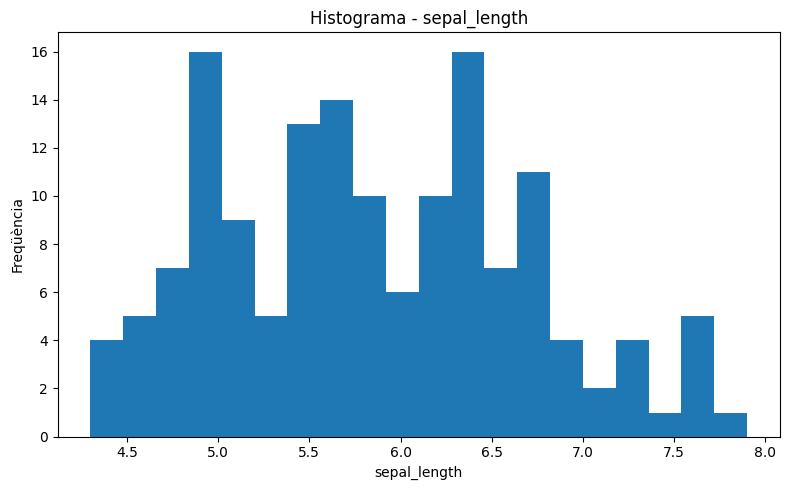

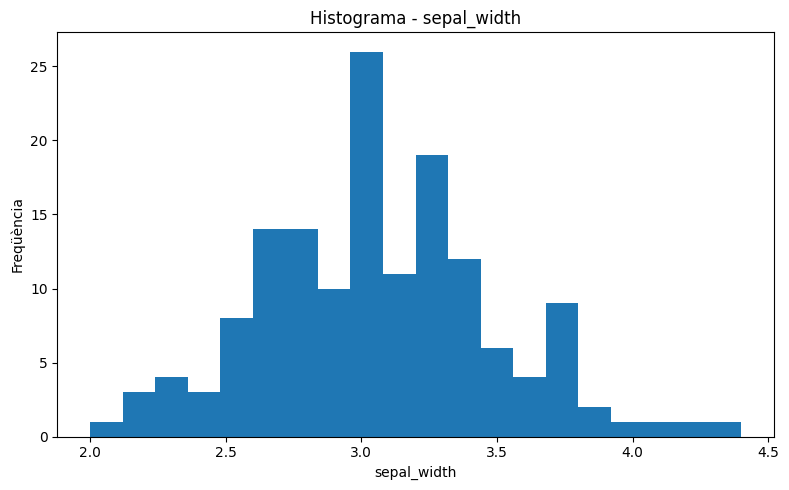

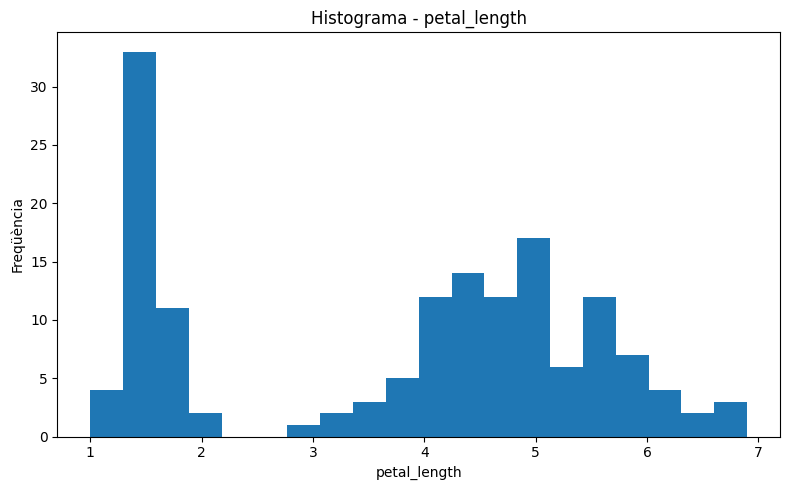

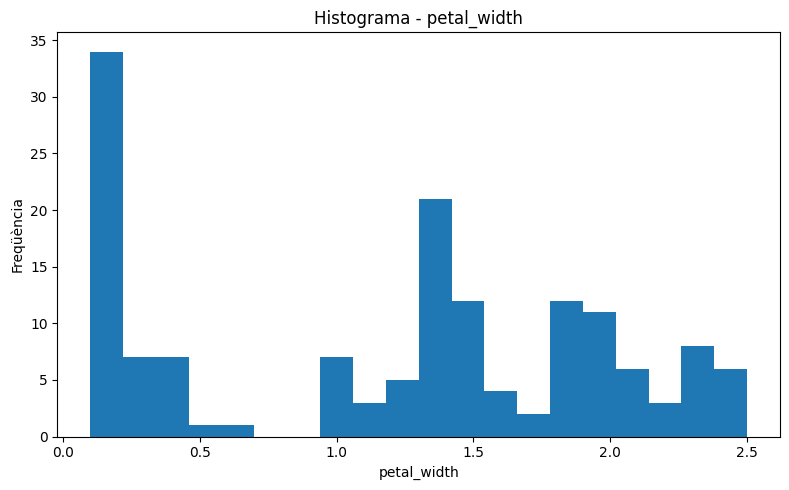

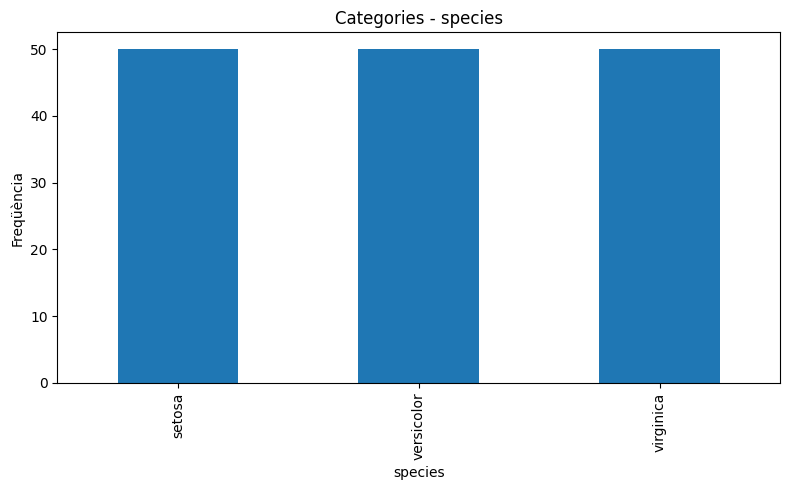

In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Función para generar gráficos automáticamente:

def explorar_dataframe(df, carpeta_sortida="grafics"):

# Crear carpeta de salida:

    os.makedirs(carpeta_sortida, exist_ok=True)

    for columna in df.columns:

        plt.figure(figsize=(8,5))

# Variables numéricas:

        if pd.api.types.is_numeric_dtype(df[columna]):

            plt.hist(
                df[columna].dropna(),
                bins=20
            )

            plt.title(f"Histograma - {columna}")
            plt.xlabel(columna)
            plt.ylabel("Freqüència")

# Variables fecha:

        elif pd.api.types.is_datetime64_any_dtype(df[columna]):

            (
                df[columna]
                .dt.year
                .value_counts()
                .sort_index()
                .plot(kind="bar")
            )

            plt.title(f"Anys - {columna}")
            plt.xlabel("Any")
            plt.ylabel("Freqüència")

# Variables categóricas:

        else:

            (
                df[columna]
                .astype(str)
                .value_counts()
                .head(10)
                .plot(kind="bar")
            )

            plt.title(f"Categories - {columna}")
            plt.xlabel(columna)
            plt.ylabel("Freqüència")

        plt.tight_layout()

# Guardar gráfico:

        plt.savefig(
            os.path.join(
                carpeta_sortida,
                f"{columna}.png"
            )
        )

        plt.show()

        plt.close()

# Ejemplo con un dataset de seaborn:

iris = sns.load_dataset("iris")

explorar_dataframe(iris)

###Respuesta:
-Se ha desarrollado una función reutilizable que permite explorar automáticamente cualquier DataFrame, identificando el tipo de cada variable y generando la representación gráfica más adecuada.
-Para las variables numéricas se generan histogramas que permiten analizar la distribución de los datos y detectar posibles valores atípicos o asimetrías.
-Para las variables categóricas se representan diagramas de barras con las categorías más frecuentes, facilitando la identificación de la distribución de cada variable.
-En el caso de variables de tipo fecha, la función agrupa los registros por año y genera un gráfico de barras con su frecuencia.
-Todos los gráficos se muestran por pantalla y, además, se exportan automáticamente en formato PNG dentro de una carpeta específica, facilitando su reutilización en informes o análisis posteriores.
-Finalmente, la función se ha validado utilizando el dataset iris incluido en la biblioteca seaborn, comprobando su correcto funcionamiento sobre un conjunto de datos externo al proyecto.

## Exercici 2: Optimització de rutes (problema aplicat)
🌍 Context: L'empresa no disposa d'un control fiable del quilometratge dels desplaçaments dels seus treballadors. Abans d'implementar un sistema avançat, es vol fer una prova pilot amb treballadors ubicats a Espanya.
Per a aquesta prova:

» Es treballa amb una matriu de distàncies entre ciutats.
»Es vol una solució simple, raonable i explicable.
» No es busca la ruta òptima, sinó una aproximació coherent.
Carrega l'arxiu matriu_distancies.xlsx a pandas de manera que les files i columnes siguin les ciutats i s'eliminin "Las Palmas de Gran Canaria" i "Palma".

Desenvolupa una funció que:

» Rebi: una ciutat d'origen i una ciutat de destinació.
» Retorni: l'ordre de les ciutats visitades (ruta) i la distància total recorreguda.
La ruta s'ha de construir seguint una estratègia senzilla: anar sempre a la ciutat no visitada més propera fins a arribar a la destinació.

In [51]:
import pandas as pd

# 1. Cargar la matriz de distancias

matriz = pd.read_excel(
    "matriu_distancies.xlsx",
    index_col=0
)

# 2. Eliminar ciudades que no participan

ciudades_eliminar = [
    "Las Palmas de Gran Canaria",
    "Palma"
]

matriz = matriz.drop(
    index=ciudades_eliminar,
    columns=ciudades_eliminar,
    errors="ignore"
)

# 3. Función de optimización de ruta

# Estrategia: vecino más cercano:

def calcular_ruta(origen, destino):

    if origen not in matriz.index:
        raise ValueError(f"La ciudad '{origen}' no existe.")

    if destino not in matriz.index:
        raise ValueError(f"La ciudad '{destino}' no existe.")

    ciudad_actual = origen

    ruta = [origen]

    distancia_total = 0

    visitadas = {origen}

    while ciudad_actual != destino:

        # Distancias desde la ciudad actual:

        distancias = matriz.loc[ciudad_actual]

        # Ciudades todavía no visitadas:

        candidatas = distancias.drop(labels=list(visitadas))

        # Si el destino todavía no se ha visitado, comprobamos si ya es la ciudad más cercana:

        if destino in candidatas.index:

            ciudad_siguiente = candidatas.idxmin()

        else:

            ciudad_siguiente = candidatas.idxmin()

        distancia_total += matriz.loc[
            ciudad_actual,
            ciudad_siguiente
        ]

        ruta.append(ciudad_siguiente)

        visitadas.add(ciudad_siguiente)

        ciudad_actual = ciudad_siguiente

        # Seguridad por si la matriz estuviera incompleta:

        if len(visitadas) == len(matriz):
            break

    return ruta, distancia_total

# 4. Ejemplo:

ruta, distancia = calcular_ruta(
    "Barcelona",
    "Sevilla"
)

print("Ruta encontrada:")

print(" -> ".join(ruta))

print(f"\nDistancia total: {distancia:.2f} km")

Ruta encontrada:
Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla

Distancia total: 1138.00 km


### Respuesta:
-Se ha cargado la matriz de distancias entre ciudades utilizando pandas, configurando las ciudades como índices y columnas de la matriz.
-Se han eliminado las ciudades Las Palmas de Gran Canaria y Palma, ya que no forman parte de la prueba piloto definida en el enunciado.
-Se ha desarrollado una función que recibe una ciudad de origen y una ciudad de destino y construye una ruta siguiendo una estrategia heurística basada en el vecino más cercano.
-En cada paso se selecciona la ciudad no visitada con menor distancia desde la posición actual hasta alcanzar el destino.
-La función devuelve tanto la secuencia de ciudades visitadas como la distancia total recorrida, proporcionando una solución sencilla, rápida y fácilmente interpretable.
-Aunque esta estrategia no garantiza obtener la ruta óptima global, resulta adecuada para una primera aproximación al problema, ya que reduce la complejidad computacional y ofrece una solución coherente con el objetivo de la prueba piloto planteada.